In [5]:
import numpy as np
import pandas as pd
import warnings
import os
import random
import pickle
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

warnings.filterwarnings("ignore")

file_path = r"C:\Users\Lenovo\Desktop\kaohsiung_5sites_final.csv"
output_dir = r"C:\Users\Lenovo\Desktop\ARIMA"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
excel_path = os.path.join(output_dir, "evaluation_metrics.xlsx")

df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
aqi_column = 'AQI'
df_wide = df.pivot(index='date', columns='sitename', values=aqi_column)
df_wide = df_wide.asfreq('H', method='ffill').sort_index()

sites = ['Meinong', 'Zuoying', 'Qianjin', 'Xiaogang', 'Linyuan']
sites = [site for site in sites if site in df_wide.columns]

site_orders = {
    'Xiaogang': (5, 1, 1),
    'Linyuan': (3, 1, 1),
    'Qianjin': (3, 1, 1),
    'Zuoying': (1, 1, 0),
    'Meinong': (5, 1, 2)
}

def arima_sample_evaluation(series, order=(3,1,0), train_hours=48, pred_hours=24, n_samples=500):  # ← 唯一修改：72 → 48
    actuals = []
    predictions = []
    max_start = len(series) - train_hours - pred_hours
    if max_start <= 0:
        return np.array([]), np.array([])
   
    sample_indices = random.sample(range(0, max_start + 1), min(n_samples, max_start + 1))
   
    for i in sample_indices:
        train = series.iloc[i:i + train_hours]
        test = series.iloc[i + train_hours:i + train_hours + pred_hours]
        try:
            model = ARIMA(train, order=order)
            model_fit = model.fit(method='innovations_mle', low_memory=True)
            forecast = model_fit.forecast(steps=pred_hours)
            predictions.extend(forecast)
            actuals.extend(test.values)
        except Exception:
            predictions.extend([train.iloc[-1]] * pred_hours)
            actuals.extend(test.values)
    return np.array(actuals), np.array(predictions)

results = {}
print(f"=== 开始处理 5 个站点，结果将保存至: {output_dir} ===\n")

for site in tqdm(sites, desc="站点处理进度", unit="站点", ncols=100):
    order = site_orders.get(site, (1, 1, 1))
    series = df_wide[site].dropna()
   
    if len(series) < 96:
        continue
   
    actual, pred = arima_sample_evaluation(series, order=order)
    if len(actual) > 0:
        rmse = np.sqrt(mean_squared_error(actual, pred))
        mae = mean_absolute_error(actual, pred)
        r2 = r2_score(actual, pred)
        results[site] = {'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R²': round(r2, 4)}
       
        try:
            final_train = series[-48:]
            model = ARIMA(final_train, order=order)
            model_fit = model.fit(method='innovations_mle', low_memory=True)
           
            model_save_path = os.path.join(output_dir, f"model_{site}.pkl")
            with open(model_save_path, 'wb') as f:
                pickle.dump(model_fit, f)
        except Exception as e:
            print(f"站点 {site} 模型保存失败: {e}")

if results:
    result_df = pd.DataFrame(results)
    final_df_to_save = result_df
   
    final_df_to_save.to_excel(excel_path)
   
    print("\n=== 评测指标汇总 ===")
    print(final_df_to_save)
    print(f"\n[成功] 指标已保存至: {excel_path}")
    print(f"[成功] 各站点 .pkl 模型文件已保存至: {output_dir}")
else:
    print("未生成任何有效结果，请检查数据。")

=== 开始处理 5 个站点，结果将保存至: C:\Users\Lenovo\Desktop\ARIMA ===



站点处理进度: 100%|█████████████████████████████████████████████████| 5/5 [05:11<00:00, 62.28s/站点]


=== 评测指标汇总 ===
      Meinong  Zuoying  Qianjin  Xiaogang  Linyuan
RMSE  19.7180  24.3070  22.8090   18.9190  21.7280
MAE   12.7150  15.8430  15.2590   13.3480  14.9470
R²     0.4654   0.4115   0.5391    0.5949   0.5662

[成功] 指标已保存至: C:\Users\Lenovo\Desktop\ARIMA\evaluation_metrics.xlsx
[成功] 各站点 .pkl 模型文件已保存至: C:\Users\Lenovo\Desktop\ARIMA


In [6]:
import numpy as np
import pandas as pd
import warnings
import os
import random
import pickle
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

warnings.filterwarnings("ignore")

file_path = r"C:\Users\Lenovo\Desktop\kaohsiung_5sites_final.csv"
output_dir = r"C:\Users\Lenovo\Desktop\ARIMA"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

excel_path = os.path.join(output_dir, "evaluation_metrics_table3.xlsx")

df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
df_wide = df.pivot(index='date', columns='sitename', values='AQI')
df_wide = df_wide.asfreq('H', method='ffill').sort_index()

sites = ['Xiaogang', 'Linyuan', 'Qianjin', 'Zuoying', 'Meinong']
site_orders = {
    'Xiaogang': (5, 1, 1), 
    'Linyuan':  (3, 1, 1), 
    'Qianjin':  (3, 1, 1), 
    'Zuoying':  (1, 1, 0), 
    'Meinong':  (5, 1, 2)
}

def arima_segmented_evaluation(series, order, train_hours=72, pred_hours=24, n_samples=300):
    """
    按时段(1-6, 7-12, 13-18, 19-24)进行抽样评估
    """
    periods = {'1-6h': [], '7-12h': [], '13-18h': [], '19-24h': []}
    actuals = {k: [] for k in periods.keys()}
    preds = {k: [] for k in periods.keys()}
    
    max_start = len(series) - train_hours - pred_hours
    if max_start <= 0: return None
    
    sample_indices = random.sample(range(0, max_start + 1), min(n_samples, max_start + 1))
    
    for i in sample_indices:
        train = series.iloc[i : i + train_hours]
        test = series.iloc[i + train_hours : i + train_hours + pred_hours]
        try:
            model = ARIMA(train, order=order)
            model_fit = model.fit(method='innovations_mle', low_memory=True)
            forecast = model_fit.forecast(steps=pred_hours)
            
            f_vals = forecast.values
            a_vals = test.values
            
            preds['1-6h'].extend(f_vals[0:6]);   actuals['1-6h'].extend(a_vals[0:6])
            preds['7-12h'].extend(f_vals[6:12]);  actuals['7-12h'].extend(a_vals[6:12])
            preds['13-18h'].extend(f_vals[12:18]); actuals['13-18h'].extend(a_vals[12:18])
            preds['19-24h'].extend(f_vals[18:24]); actuals['19-24h'].extend(a_vals[18:24])
            
        except:
            continue
            
    segment_results = {}
    for p in periods.keys():
        if len(actuals[p]) > 0:
            act = np.array(actuals[p])
            pre = np.array(preds[p])
            segment_results[p] = {
                'RMSE': round(np.sqrt(mean_squared_error(act, pre)), 4),
                'MAE': round(mean_absolute_error(act, pre), 4),
                'R²': round(r2_score(act, pre), 4)
            }
    return segment_results

all_data = []

print(f"开始基于特定参数计算 5 个站点的时段指标...")

for site in tqdm(sites, desc="站点进度"):
    order = site_orders.get(site, (1, 1, 1))
    series = df_wide[site].dropna()
    
    seg_res = arima_segmented_evaluation(series, order)
    
    if seg_res:
        for period, metrics in seg_res.items():
            for m_name, m_val in metrics.items():
                all_data.append({
                    '评价指标': m_name,
                    '时间段': period,
                    'Site': site,
                    'Value': m_val
                })

        final_model = ARIMA(series[-72:], order=order).fit(method='innovations_mle')
        with open(os.path.join(output_dir, f"model_{site}.pkl"), 'wb') as f:
            pickle.dump(final_model, f)

final_df = pd.DataFrame(all_data)
table_3 = final_df.pivot_table(index=['时间段', '评价指标'], columns='Site', values='Value')

metric_order = ['RMSE', 'MAE', 'R²']
period_order = ['1-6h', '7-12h', '13-18h', '19-24h']
new_index = pd.MultiIndex.from_product([period_order, metric_order], names=['时间段', '评价指标'])

table_3 = table_3.reindex(new_index)
table_3 = table_3[sites] 

table_3.to_excel(excel_path)

print("\n=== 表 3 最终结果预览 ===")
print(table_3)
print(f"\n[成功] 格式化表格已保存至: {excel_path}")

开始基于特定参数计算 5 个站点的时段指标...


站点进度: 100%|██████████████████████████████████████████████████████████████████████████| 5/5 [03:03<00:00, 36.60s/it]


=== 表 3 最终结果预览 ===
Site         Xiaogang  Linyuan  Qianjin  Zuoying  Meinong
时间段    评价指标                                              
1-6h   RMSE   10.4828  13.2432  11.9630  12.4299   9.8010
       MAE     6.9144   8.3952   7.6266   7.5321   6.4443
       R²      0.8746   0.8477   0.8641   0.8373   0.8634
7-12h  RMSE   16.7926  20.8950  21.8331  22.3440  18.2561
       MAE    12.1521  14.7741  15.0850  15.8977  12.8943
       R²      0.6661   0.6394   0.5854   0.4987   0.4896
13-18h RMSE   18.6745  25.3173  24.2089  26.0329  19.9535
       MAE    13.5742  17.9278  16.9707  18.6722  14.1057
       R²      0.5538   0.4487   0.5041   0.3384   0.4584
19-24h RMSE   19.2059  25.8307  22.7442  26.5830  19.3428
       MAE    14.0031  18.7599  16.1616  18.7902  13.5943
       R²      0.5652   0.4215   0.5380   0.2835   0.4989

[成功] 格式化表格已保存至: C:\Users\Lenovo\Desktop\ARIMA\evaluation_metrics_table3.xlsx


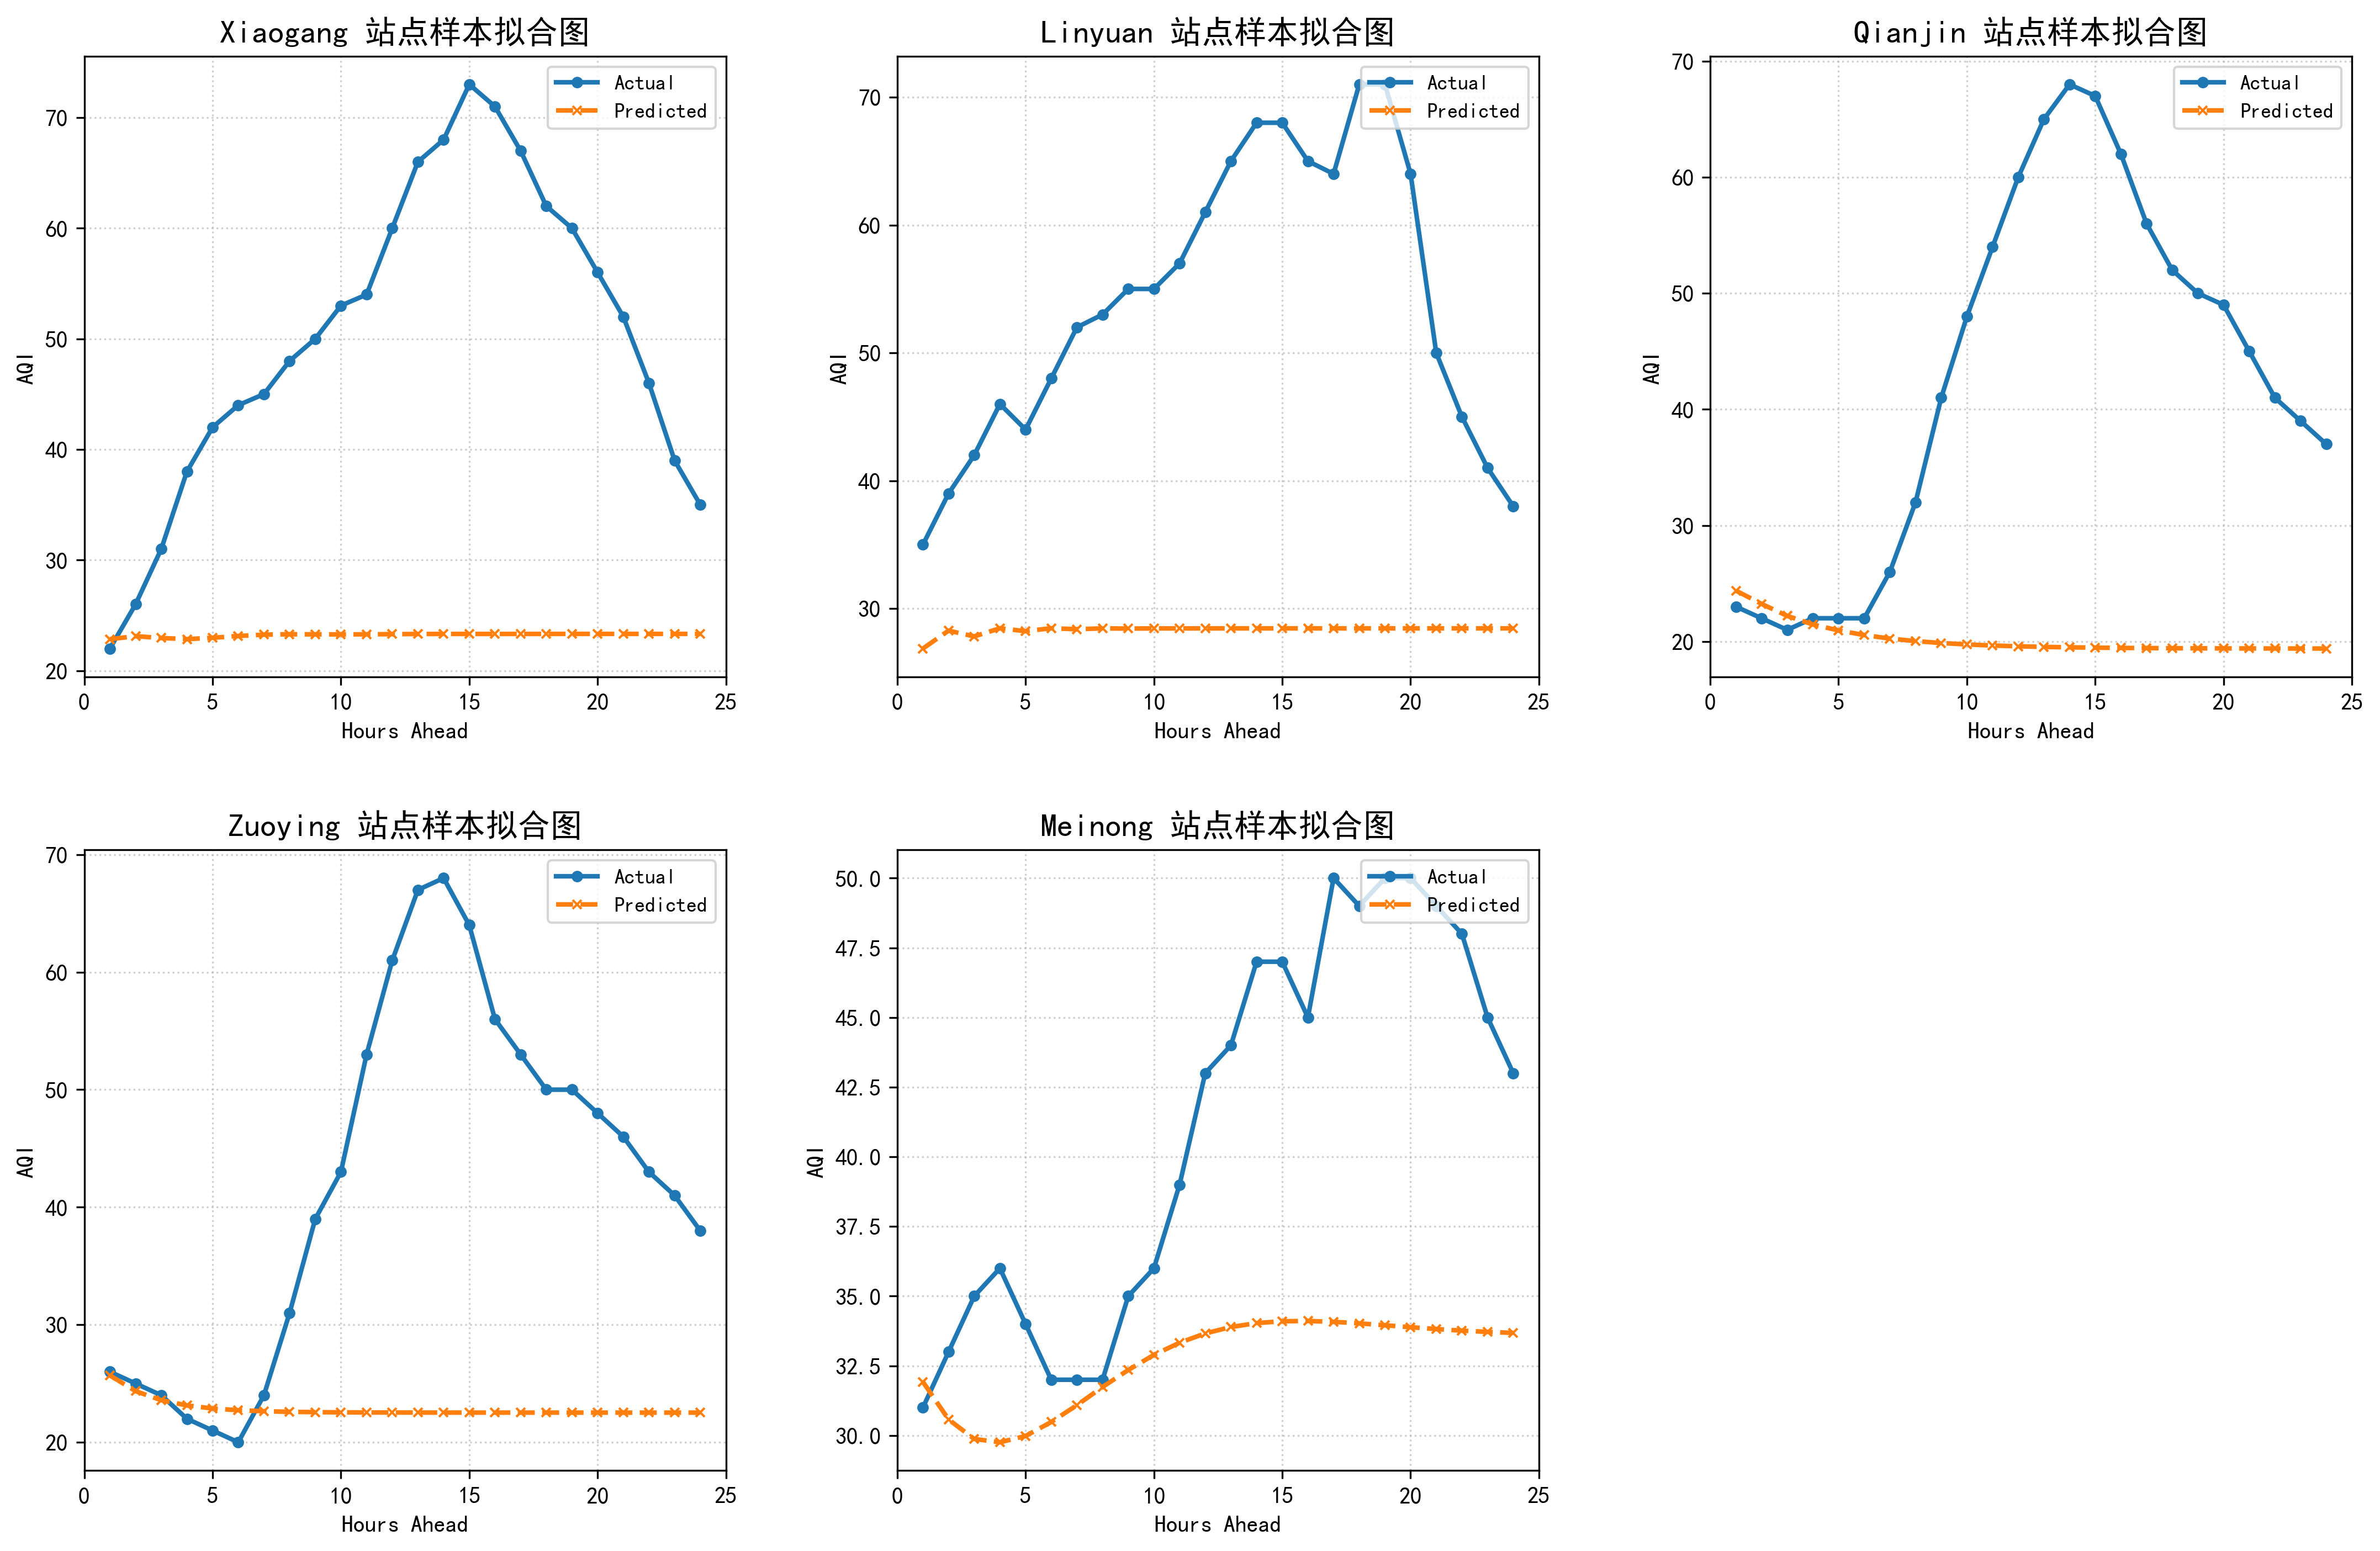


任务完成！拟合图已导出至: C:\Users\Lenovo\Desktop\ARIMA\Figure_Combined_Site_Fitting.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

file_path = r"C:\Users\Lenovo\Desktop\kaohsiung_5sites_final.csv"
base_dir = r"C:\Users\Lenovo\Desktop\ARIMA"

sites = ['Xiaogang', 'Linyuan', 'Qianjin', 'Zuoying', 'Meinong']
site_orders = {
    'Xiaogang': (5, 1, 1), 'Linyuan': (3, 1, 1), 
    'Qianjin': (3, 1, 1), 'Zuoying': (1, 1, 0), 'Meinong': (5, 1, 2)
}

df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
df_wide = df.pivot(index='date', columns='sitename', values='AQI').asfreq('H', method='ffill').sort_index()

fig = plt.figure(figsize=(15, 10), dpi=300)

for i, site in enumerate(sites):
    ax = fig.add_subplot(2, 3, i+1)
    
    order = site_orders.get(site, (1, 1, 1))
    series = df_wide[site].dropna()
    
    actual = series.tail(24)
    train = series.iloc[-96:-24] 
    
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit(method='innovations_mle')
        preds = model_fit.forecast(steps=24)

        ax.plot(range(1, 25), actual.values, color='#1f77b4', label='Actual', 
                linewidth=2, marker='o', markersize=4)
        ax.plot(range(1, 25), preds.values, color='#ff7f0e', label='Predicted', 
                linewidth=2, linestyle='--', marker='x', markersize=4)

        ax.set_title(f"{site} 站点样本拟合图", fontsize=14, fontweight='bold')
        
        ax.set_xlabel("Hours Ahead", fontsize=10)
        ax.set_ylabel("AQI", fontsize=10)
        
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, 25)
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Fitting Error: {site}", ha='center')
        print(f"站点 {site} 处理失败: {e}")

plt.tight_layout(pad=3.0)

combined_save_path = os.path.join(base_dir, "Figure_Combined_Site_Fitting.png")
plt.savefig(combined_save_path, bbox_inches='tight')
plt.show()

print(f"\n任务完成！拟合图已导出至: {combined_save_path}")

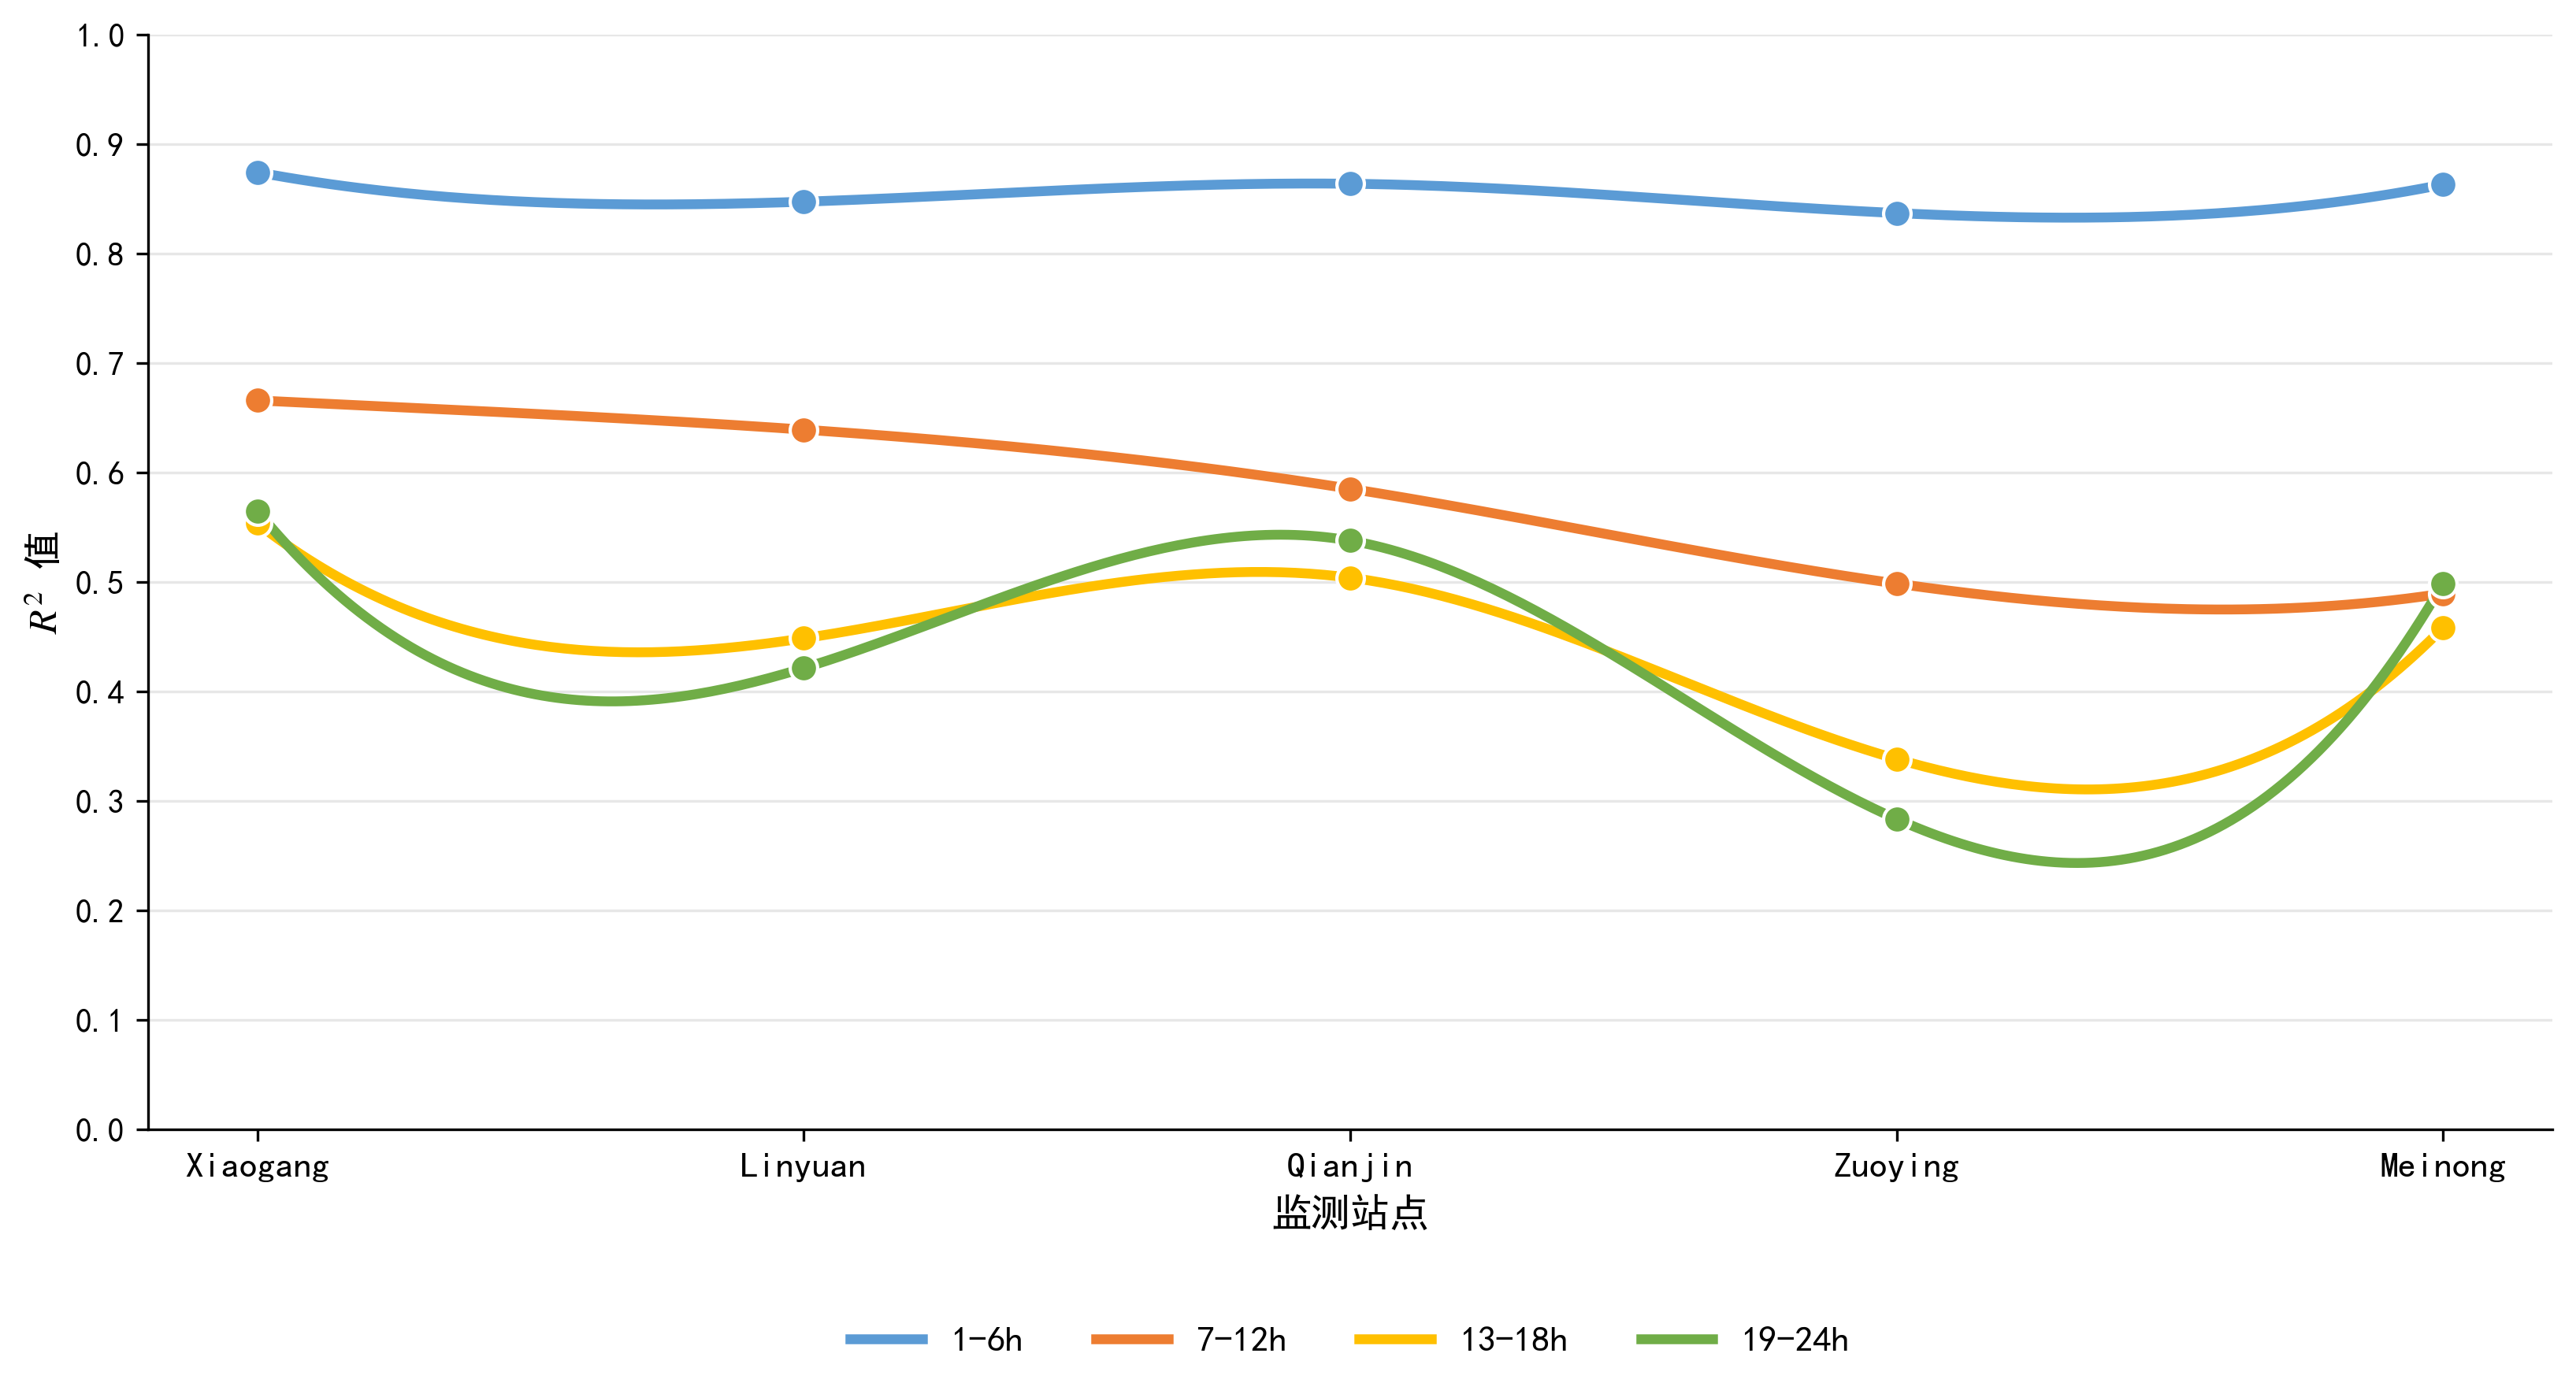

图表已成功生成并保存至: C:\Users\Lenovo\Desktop\ARIMA\Figure_7_Final.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 支持中文显示
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stix'

# 文件路径
file_path = r"C:\Users\Lenovo\Desktop\ARIMA\evaluation_metrics_table3.xlsx"

try:
    df = pd.read_excel(file_path)
    df['时间段'] = df['时间段'].fillna(method='ffill')
except Exception as e:
    print(f"读取文件出错，请检查路径或文件是否被占用: {e}")
    exit()

# 站点顺序
sites = ['Xiaogang', 'Linyuan', 'Qianjin', 'Zuoying', 'Meinong']
periods = ['1-6h', '7-12h', '13-18h', '19-24h']

# 提取每个时间段的 R² 值
r2_data = {}
for p in periods:
    row = df[(df['时间段'] == p) & (df['评价指标'] == 'R²')]
    if not row.empty:
        r2_data[p] = [row[site].values[0] for site in sites]

# 绘图
plt.figure(figsize=(11, 6), dpi=300)
colors = ['#5b9bd5', '#ed7d31', '#ffc000', '#70ad47']

x_numeric = np.arange(len(sites))
x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 300)

for i, (label, values) in enumerate(r2_data.items()):
    spline = make_interp_spline(x_numeric, values, k=3)
    y_smooth = spline(x_smooth)
    
    plt.plot(x_smooth, y_smooth, label=label, color=colors[i], linewidth=3, zorder=2)
    plt.scatter(x_numeric, values, color=colors[i], s=70, edgecolors='white', linewidth=1, zorder=3)

plt.ylabel(r"$R^2$ 值", fontsize=12, fontweight='bold')
plt.xlabel("监测站点", fontsize=12, fontweight='bold')
plt.xticks(x_numeric, sites, fontsize=11, fontweight='bold')

# === 唯一修改的部分：y轴范围从0.3改为0.0，避免低值数据被裁剪到图外 ===
plt.ylim(0.0, 1.0)
plt.yticks(np.arange(0.0, 1.1, 0.1))

plt.grid(axis='y', linestyle='-', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=4, frameon=False, prop={'size': 11, 'weight': 'bold'})

plt.tight_layout()

# 保存路径
save_path = r"C:\Users\Lenovo\Desktop\ARIMA\Figure_7_Final.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f"图表已成功生成并保存至: {save_path}")

In [11]:
import pandas as pd
import os

base_dir = r"C:\Users\Lenovo\Desktop\ARIMA"
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

save_path = os.path.join(base_dir, "ARIMA_Model_Configurations.xlsx")

site_params = "Xiaogang(5,1,1), Linyuan(3,1,1), Qianjin(3,1,1), Zuoying(1,1,0), Meinong(5,1,2)"

config_data = [
    ["输入 / 输出", "历史训练窗口", "48 小时"],
    ["", "预测时长", "24 小时"],
    ["", "数据频率", "1 小时 (Hourly)"],
    
    ["ARIMA 模块", "模型名称", "Autoregressive Integrated Moving Average"],
    ["", "站点特定阶数 (p, d, q)", site_params],
    ["", "自回归阶数 (p) 范围", "1 ~ 5"],
    ["", "差分阶数 (d)", "1 (针对非平稳序列)"],
    ["", "移动平均阶数 (q) 范围", "0 ~ 2"],
    ["", "趋势项 (Trend)", "无 (已通过一阶差分消除)"],
    
    ["算法与配置", "参数估计方法", "Innovations MLE (创新极大似然估计)"],
    ["", "计算引擎", "Statsmodels.tsa.arima"],
    ["", "低内存模式", "True (low_memory=True)"],
    
    ["评估与验证", "验证策略", "分段抽样评估 (Segmented Evaluation)"],
    ["", "样本采样数", "300"],
    ["", "评价指标", "RMSE, MAE, R²"]
]

df_config = pd.DataFrame(config_data, columns=["类别", "参数名称", "参数值"])

with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
    df_config.to_excel(writer, index=False, sheet_name='ARIMA配置')
    
    worksheet = writer.sheets['ARIMA配置']
    worksheet.column_dimensions['A'].width = 20
    worksheet.column_dimensions['B'].width = 25
    worksheet.column_dimensions['C'].width = 60

print(f"=== ARIMA 模型配置表生成成功 ===")
print(f"文件位置: {save_path}")
print("-" * 50)
print(df_config)

=== ARIMA 模型配置表生成成功 ===
文件位置: C:\Users\Lenovo\Desktop\ARIMA\ARIMA_Model_Configurations.xlsx
--------------------------------------------------
          类别              参数名称  \
0    输入 / 输出            历史训练窗口   
1                         预测时长   
2                         数据频率   
3   ARIMA 模块              模型名称   
4             站点特定阶数 (p, d, q)   
5                 自回归阶数 (p) 范围   
6                     差分阶数 (d)   
7                移动平均阶数 (q) 范围   
8                  趋势项 (Trend)   
9      算法与配置            参数估计方法   
10                        计算引擎   
11                       低内存模式   
12     评估与验证              验证策略   
13                       样本采样数   
14                        评价指标   

                                                  参数值  
0                                               48 小时  
1                                               24 小时  
2                                       1 小时 (Hourly)  
3            Autoregressive Integrated Moving Average  
4   Xiaogang(5,1,1), Linyuan(3,1